In [3]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
wine = load_wine()
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

    :Number of Instances: 178
    :Number of Attributes: 13 numeric, predictive attributes and the class
    :Attribute Information:
 		- Alcohol
 		- Malic acid
 		- Ash
		- Alcalinity of ash  
 		- Magnesium
		- Total phenols
 		- Flavanoids
 		- Nonflavanoid phenols
 		- Proanthocyanins
		- Color intensity
 		- Hue
 		- OD280/OD315 of diluted wines
 		- Proline

    - class:
            - class_0
            - class_1
            - class_2
		
    :Summary Statistics:
    
    ============================= ==== ===== ======= =====
                                   Min   Max   Mean     SD
    ============================= ==== ===== ======= =====
    Alcohol:                      11.0  14.8    13.0   0.8
    Malic Acid:                   0.74  5.80    2.34  1.12
    Ash:                          1.36  3.23    2.36  0.27
    Alcalinity of Ash:            10.6  30.0    19.5   3.3
    Ma

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(wine.data, wine.target, test_size=0.2, random_state = 156)

In [14]:
from sklearn.tree import DecisionTreeClassifier

dt_HAR = DecisionTreeClassifier(random_state = 156)

In [15]:
dt_HAR.fit(X_train, Y_train)

DecisionTreeClassifier(random_state=156)

In [16]:
Y_predict = dt_HAR.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(Y_test, Y_predict)
print('결정 트리 예측 정확도: {0:.4f}'.format(accuracy))

결정 트리 예측 정확도: 0.9444


In [18]:
from sklearn.model_selection import GridSearchCV

In [25]:
params = {
    'max_depth': [4, 5, 6],
    'min_samples_split': [5, 6, 7, 8, 9, 10]
}

grid_cv = GridSearchCV(dt_HAR, param_grid = params, scoring = 'accuracy', cv = 5, return_train_score = True)
grid_cv.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=156),
             param_grid={'max_depth': [4, 5, 6],
                         'min_samples_split': [5, 6, 7, 8, 9, 10]},
             return_train_score=True, scoring='accuracy')

In [26]:
cv_results_df = pd.DataFrame(grid_cv.cv_results_)

cv_results_df[['param_max_depth', 'param_min_samples_split', 'mean_test_score', 'mean_train_score']]

,param_max_depth,param_min_samples_split,mean_test_score,mean_train_score
0,4,5,0.844828,0.985856
1,4,6,0.851724,0.982316
2,4,7,0.851724,0.982316
3,4,8,0.851724,0.982316
4,4,9,0.851724,0.982316
5,4,10,0.837438,0.977053
6,5,5,0.858621,0.994706
7,5,6,0.865517,0.991166
8,5,7,0.865517,0.991166
9,5,8,0.865517,0.991166


In [27]:
print('최고 평균 정확도: {0:.4f}, 최적 하이퍼 매개변수: {1}'.format(grid_cv.best_score_, grid_cv.best_params_))

최고 평균 정확도: 0.8655, 최적 하이퍼 매개변수: {'max_depth': 5, 'min_samples_split': 6}


In [28]:
best_dt_HAR = grid_cv.best_estimator_
best_Y_predict = best_dt_HAR.predict(X_test)
best_accuracy = accuracy_score(Y_test, best_Y_predict)

print('best 결정 트리 예측 정확도: {0:.4f}'.format(best_accuracy))

best 결정 트리 예측 정확도: 0.9722


Feature importances:
[0.005 0.029 0.    0.    0.016 0.    0.143 0.017 0.    0.041 0.054 0.295
 0.399]
alcohol : 0.005
malic_acid : 0.029
ash : 0.000
alcalinity_of_ash : 0.000
magnesium : 0.016
total_phenols : 0.000
flavanoids : 0.143
nonflavanoid_phenols : 0.017
proanthocyanins : 0.000
color_intensity : 0.041
hue : 0.054
od280/od315_of_diluted_wines : 0.295
proline : 0.399


<Axes: >

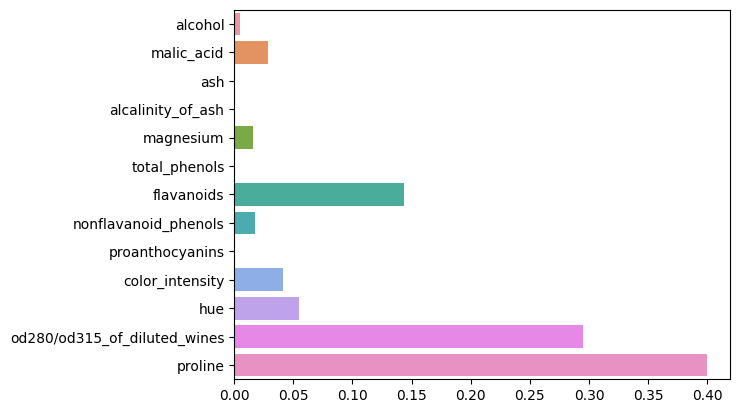

In [30]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

print('Feature importances:\n{0}'.format(np.round(dt_HAR.feature_importances_, 3)))

# feature 별 importance 매핑
for name, value in zip(wine.feature_names, dt_HAR.feature_importances_):
    print('{0} : {1:.3f}'.format(name, value))

# feature importance를 column 별로 시각화하기
sns.barplot(x=dt_HAR.feature_importances_, y=wine.feature_names)

In [31]:
!pip install graphviz

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


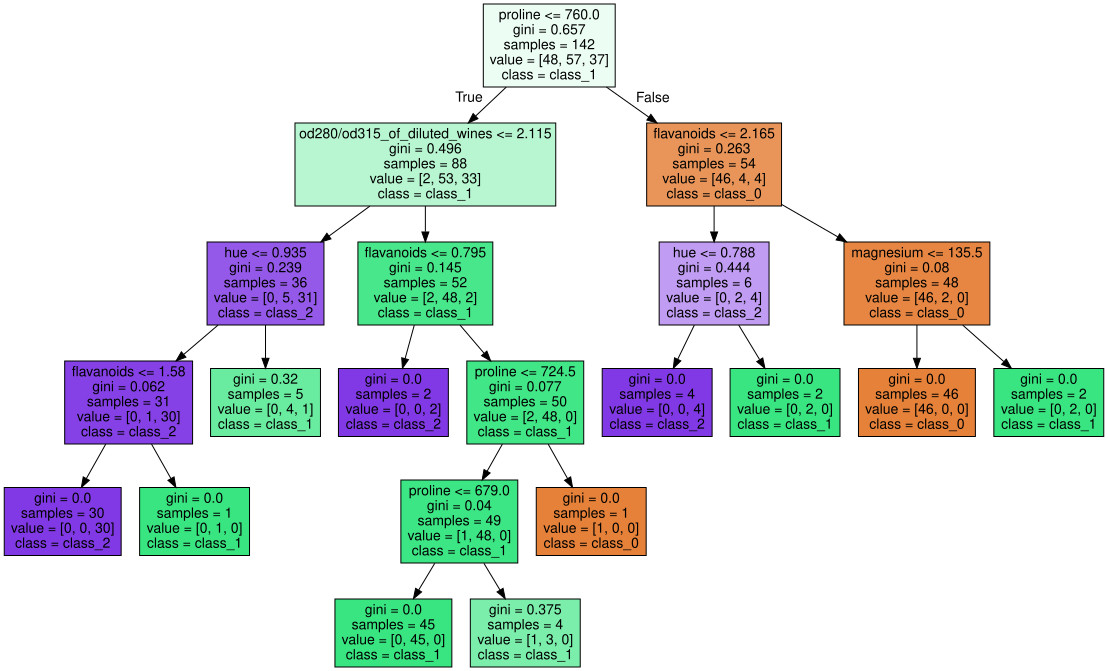

In [32]:
from sklearn.tree import export_graphviz

import graphviz

export_graphviz(best_dt_HAR, out_file = "tree.dot", class_names = wine.target_names, feature_names = wine.feature_names, impurity = True, filled = True)

#위에서 생성된 tree.dot 파일을 Graphviz가 읽어서 시각화
with open("tree.dot") as f:
    dot_graph = f.read()

graphviz.Source(dot_graph)